# Dia 3 · Módulo 9 — Lendo resultados de IA com olhos de estatístico
### Estatística Básica Aplicada · Python

Este é o módulo de fechamento do curso. Aqui os três dias convergem — e você vai descobrir que
**não precisa aprender nada novo** para julgar criticamente um resultado de inteligência
artificial. Tudo o que é preciso já foi visto:

| O que aparece num resultado de IA | O que ele é, estatisticamente | Onde você viu |
|---|---|---|
| a **acurácia** de um modelo | uma **média** | Dia 1, Módulo 1 |
| o modelo em si | uma máquina de **correlação** | Dia 2, Módulos 4 e 5 |
| a "importância das variáveis" | associação, **não** causa | Dia 2, Módulo 6 |
| o **conjunto de treino** | uma **amostra** | Dia 3, Módulo 7 |
| "o modelo A é melhor que o B" | uma **diferença que pode ser acaso** | Dia 3, Módulo 8 |

> ## O que perguntar antes de acreditar num número de IA?

**O que a turma vai levar deste módulo:**
1. **Acurácia é uma média** — e média esconde, como sempre escondeu.
2. Qual erro custa caro **na sua operação**: alarme falso ou ameaça não detectada?
3. **Overfitting é decorar o ruído** — e é por isso que se separa treino de teste.
4. O desempenho médio **esconde subgrupos** — o piloto médio de Daniels, de volta.
5. Diferença entre modelos num *benchmark* precisa de **erro padrão** para significar algo.

> ⚠️ Você não precisa escrever código do zero: **ler → prever → rodar → interpretar → modificar**.

## Roteiro e tempo

| Seção | Assunto | Ideia central |
|---|---|---|
| ⓪ | 99% de acurácia, zero utilidade | acurácia é média, e média engana |
| ① | Matriz de confusão | os dois erros não custam a mesma coisa |
| ② | Treino × teste | overfitting é decorar o ruído |
| ③ | O desempenho médio esconde subgrupos | Daniels, de volta |
| ④ | "91,2% × 90,8%" | isso é diferença ou é acaso? |
| ⑤ | O mundo mudou depois do treino | deslocamento de distribuição |
| ⑥ | Checklist para ler um artigo de IA | |

In [4]:
# --- Preparação do ambiente ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

COR = {
    "media":   "#2a78d6",   # azul
    "dados":   "#9ec5f4",   # azul claro
    "verdade": "#1baf7a",   # verde    — o valor real / o acerto
    "alerta":  "#e34948",   # vermelho — o erro
    "treino":  "#4a3aa7",   # violeta  — desempenho no treino
    "teste":   "#eb6834",   # laranja  — desempenho no teste
    "neutro":  "#898781",
}

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.labelcolor": "#52514e", "xtick.color": "#898781", "ytick.color": "#898781",
    "font.size": 10, "lines.linewidth": 2, "figure.dpi": 110,
})

print("Ambiente pronto.")

Ambiente pronto.


---
# ⓪ 99% de acurácia e utilidade zero

> Uma empresa apresenta ao comando um sistema de IA para **prever falha crítica de viatura**
> antes da operação. O resultado: **99% de acurácia**. O contrato está prestes a ser assinado.

**Antes de rodar:** falhas críticas acontecem em cerca de 1% das viaturas. Que modelo trivial
consegue 99% de acurácia nesse problema?

In [5]:
# --- O modelo mais preguiçoso do mundo ---
rng = np.random.default_rng(6)
NV = 5000

# a realidade: 1% das viaturas vai apresentar falha crítica
vai_falhar = rng.random(NV) < 0.01

# o "modelo": responde SEMPRE que está tudo bem. Não olha nada. Não aprendeu nada.
previsao_preguicosa = np.zeros(NV, dtype=bool)

acuracia = np.mean(previsao_preguicosa == vai_falhar)

print(f"viaturas avaliadas          : {NV}")
print(f"viaturas que realmente falham: {vai_falhar.sum()}")
print(f"\nACURÁCIA do modelo: {acuracia:.1%}")
print("\nE o que esse modelo faz? Responde 'está tudo bem' para TODAS as viaturas.")
print("Ele não olha um único dado. Poderia ser um pedaço de papel escrito 'OK'.")
print(f"\nDas {vai_falhar.sum()} viaturas que iam falhar, ele avisou sobre: 0")
print("\nA acurácia é uma MÉDIA de acertos. E média, como o Dia 1 inteiro mostrou,")
print("esconde exatamente aquilo que interessa quando os grupos são desbalanceados.")

viaturas avaliadas          : 5000
viaturas que realmente falham: 48

ACURÁCIA do modelo: 99.0%

E o que esse modelo faz? Responde 'está tudo bem' para TODAS as viaturas.
Ele não olha um único dado. Poderia ser um pedaço de papel escrito 'OK'.

Das 48 viaturas que iam falhar, ele avisou sobre: 0

A acurácia é uma MÉDIA de acertos. E média, como o Dia 1 inteiro mostrou,
esconde exatamente aquilo que interessa quando os grupos são desbalanceados.


> ### 🔑 A ideia central do módulo
> **Acurácia é a média de acertos — e o evento que importa costuma ser o raro.**
>
> Quanto mais raro e mais grave o evento (falha crítica, fraude, ameaça, doença), **mais inútil**
> a acurácia se torna como medida única. É o mesmo problema do Módulo 1: um número de centro
> não descreve o que acontece na **cauda** — e a decisão mora na cauda (Módulo 2, §4.3).

**Ao ler um resultado de IA, a primeira pergunta é sempre:** *qual a proporção de cada classe
nos dados?* Sem isso, "95% de acurácia" não tem como ser interpretado.

---
# ① Matriz de confusão: os dois erros são diferentes

Como a acurácia junta tudo num número só, é preciso abrir os acertos e os erros em **quatro**
caixas. Essa tabela se chama **matriz de confusão**, e é a base de tudo que se reporta em IA.

|  | modelo diz **vai falhar** | modelo diz **está OK** |
|---|---|---|
| **realmente falhou** | ✅ verdadeiro positivo (VP) | ❌ **falso negativo (FN)** — a viatura quebrou em operação |
| **realmente OK** | ❌ **falso positivo (FP)** — recolhida à toa | ✅ verdadeiro negativo (VN) |

Os dois erros **não custam a mesma coisa**:

- **Falso positivo:** você recolhe uma viatura boa. Custo: manutenção desnecessária, indisponibilidade.
- **Falso negativo:** a viatura sai e quebra na operação. Custo: missão comprometida, risco à tropa.

Dessas quatro caixas saem as duas medidas que você mais vai encontrar em artigos:

- **Recall** (ou sensibilidade) = `VP / (VP + FN)` → *das falhas reais, quantas eu peguei?*
- **Precisão** = `VP / (VP + FP)` → *dos meus alarmes, quantos eram de verdade?*

É o que chamamos aqui no **PROBLEMA DO DESBALANCEAMENTO**

In [6]:
# --- Um modelo de verdade, com algum poder de detecção ---
rng1 = np.random.default_rng(14)
NV2 = 5000
falha = rng1.random(NV2) < 0.01                       # 1% falham de fato

# o modelo produz um SCORE de risco: quem vai falhar tende a ter score maior (mas há sobreposição)
score = np.where(falha, rng1.normal(2.2, 1.0, NV2), rng1.normal(0.0, 1.0, NV2))

def avaliar(corte):
    alarme = score > corte
    vp = np.sum(alarme & falha)
    fp = np.sum(alarme & ~falha)
    fn = np.sum(~alarme & falha)
    vn = np.sum(~alarme & ~falha)
    acc = (vp + vn) / NV2
    rec = vp / (vp + fn) if (vp + fn) else 0.0
    pre = vp / (vp + fp) if (vp + fp) else 0.0
    return vp, fp, fn, vn, acc, rec, pre

print(f"{'corte':>6} | {'VP':>4} | {'FP':>5} | {'FN':>4} | {'VN':>4} | {'acurácia':>9} | {'recall':>8} | {'precisão':>9}")
print("-" * 75)
for c in [3.5, 2.5, 1.5, 0.5, -0.5]:
    vp, fp, fn, vn, acc, rec, pre = avaliar(c)
    print(f"{c:>6.1f} | {vp:>4} | {fp:>5} | {fn:>4} | {vn:>4} | {acc:>8.1%} | {rec:>7.1%} | {pre:>8.1%}")
    assert vp + fp + fn + vn == NV2   # as quatro caixas sempre fecham o total

print("\nRepare que a ACURÁCIA quase não se mexe (fica sempre perto de 99%) — ela é inútil aqui.")
print("Quem conta a história são o recall e a precisão, e eles PUXAM EM SENTIDOS OPOSTOS:")
print("  corte alto  -> poucos alarmes, quase todos certos, mas você PERDE muitas falhas")
print("  corte baixo -> pega quase todas as falhas, mas enche a oficina de viatura boa")

 corte |   VP |    FP |   FN |   VN |  acurácia |   recall |  precisão
---------------------------------------------------------------------------
   3.5 |    3 |     0 |   43 | 4954 |    99.1% |    6.5% |   100.0%
   2.5 |   15 |    30 |   31 | 4924 |    98.8% |   32.6% |    33.3%
   1.5 |   37 |   332 |    9 | 4622 |    93.2% |   80.4% |    10.0%
   0.5 |   46 |  1616 |    0 | 3338 |    67.7% |  100.0% |     2.8%
  -0.5 |   46 |  3474 |    0 | 1480 |    30.5% |  100.0% |     1.3%

Repare que a ACURÁCIA quase não se mexe (fica sempre perto de 99%) — ela é inútil aqui.
Quem conta a história são o recall e a precisão, e eles PUXAM EM SENTIDOS OPOSTOS:
  corte alto  -> poucos alarmes, quase todos certos, mas você PERDE muitas falhas
  corte baixo -> pega quase todas as falhas, mas enche a oficina de viatura boa


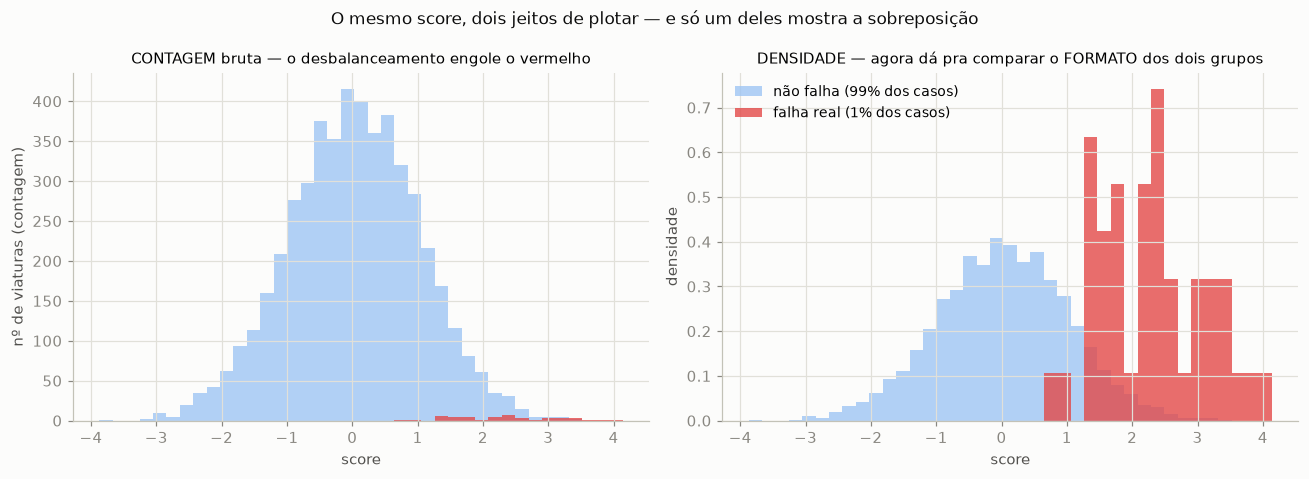

No painel da ESQUERDA, as 46 viaturas que falham (vermelho) ficam achatadas
perto do eixo x, escondidas atrás das 4954 que não falham (azul) — mesmo
problema da acurácia: o grupo grande domina visualmente o grupo raro.

No painel da DIREITA, cada histograma foi normalizado pela sua própria contagem (density=True),
então os dois sinos aparecem do mesmo tamanho — o que se compara ali é a FORMA, não a quantidade.

Repare na faixa onde azul e vermelho se misturam (mais ou menos entre 0 e 3): TODO corte
ali dentro vai errar de um jeito ou de outro — ou perde falha (FN) ou solta alarme à toa (FP).
Não existe uma linha vertical que separe limpo o vermelho do azul — é por isso que recall
e precisão nunca sobem juntos na tabela acima.


In [12]:
# --- Onde estão os dois grupos, de fato? ---
bins = np.linspace(score.min(), score.max(), 40)

fig, (eixo_ct, eixo_dens) = plt.subplots(1, 2, figsize=(12, 4.4))

for eixo, usar_densidade, titulo in [
    (eixo_ct,   False, "CONTAGEM bruta — o desbalanceamento engole o vermelho"),
    (eixo_dens, True,  "DENSIDADE — agora dá pra comparar o FORMATO dos dois grupos"),
]:
    eixo.hist(score[~falha], bins=bins, density=usar_densidade, color=COR["dados"], alpha=0.8,
              label="não falha (99% dos casos)")
    eixo.hist(score[falha], bins=bins, density=usar_densidade, color=COR["alerta"], alpha=0.8,
              label="falha real (1% dos casos)")
    eixo.set_title(titulo, fontsize=9.5)
    eixo.set_xlabel("score")

eixo_ct.set_ylabel("nº de viaturas (contagem)")
eixo_dens.set_ylabel("densidade")
eixo_dens.legend(frameon=False, fontsize=9)
fig.suptitle("O mesmo score, dois jeitos de plotar — e só um deles mostra a sobreposição",
             fontsize=11, color="#0b0b0b")
plt.tight_layout()
plt.show()

print(f"No painel da ESQUERDA, as {falha.sum()} viaturas que falham (vermelho) ficam achatadas")
print(f"perto do eixo x, escondidas atrás das {(~falha).sum()} que não falham (azul) — mesmo")
print("problema da acurácia: o grupo grande domina visualmente o grupo raro.")
print("\nNo painel da DIREITA, cada histograma foi normalizado pela sua própria contagem (density=True),")
print("então os dois sinos aparecem do mesmo tamanho — o que se compara ali é a FORMA, não a quantidade.")
print("\nRepare na faixa onde azul e vermelho se misturam (mais ou menos entre 0 e 3): TODO corte")
print("ali dentro vai errar de um jeito ou de outro — ou perde falha (FN) ou solta alarme à toa (FP).")
print("Não existe uma linha vertical que separe limpo o vermelho do azul — é por isso que recall")
print("e precisão nunca sobem juntos na tabela acima.")

> ### A pergunta que decide o corte não é estatística — é operacional
>
> Não existe corte "correto". Existe o corte que equilibra os dois custos **da sua operação**:
>
> - Numa triagem de **ameaça**, um falso negativo pode custar vidas → priorize **recall**.
> - Num alarme que **para a operação** a cada disparo, falso positivo desgasta e faz a tropa
>   ignorar o sistema → priorize **precisão**.
> - Às vezes o custo é só **dinheiro**, e dinheiro também é custo real: perseguir a última falha
>   rara pode significar mandar um número absurdo de viaturas **boas** para manutenção preventiva
>   desnecessária. Se essa manutenção é cara, pode sair mais barato **aceitar** que algumas falhas
>   raras não sejam pegas do que caçar 100% delas.
>
> Um artigo que reporta **só a acurácia** está escondendo essa escolha de você. Um artigo que
> reporta recall e precisão está te entregando a decisão — que é o certo, porque a escolha
> depende do custo de cada erro, e quem conhece esse custo é você, não quem treinou o modelo.

**Veja o preço disso na própria tabela:** sair do corte `1.5` para `0.5` pega as últimas 9 falhas
reais (recall vai de 80,4% para 100%) — mas custa **1.284 viaturas boas a mais** na manutenção
(FP sobe de 332 para 1.616). Se cada manutenção preventiva tem um custo real, a pergunta vira:
*vale a pena gastar com 1.284 viaturas boas para pegar 9 falhas a mais?* Não tem resposta
estatística para isso — só quem paga a conta sabe.

---
# ② Treino × teste: overfitting é decorar o ruído

Todo modelo de IA aprende a partir de **exemplos**. A pergunta que importa não é "ele acerta os
exemplos que já viu?" — e sim "ele acerta os casos **novos**?".

Um modelo suficientemente flexível consegue passar **exatamente** por todos os pontos de treino.
Ao fazer isso, ele não aprendeu a regra: ele **decorou** os dados, inclusive o ruído aleatório
que havia neles.

Isso é o Módulo 5 (regressão) com uma curva flexível demais. E a demonstração é a mesma.

**Antes de rodar:** entre uma reta, uma curva suave e uma curva que passa por todos os pontos,
qual vai acertar melhor os **casos novos**?

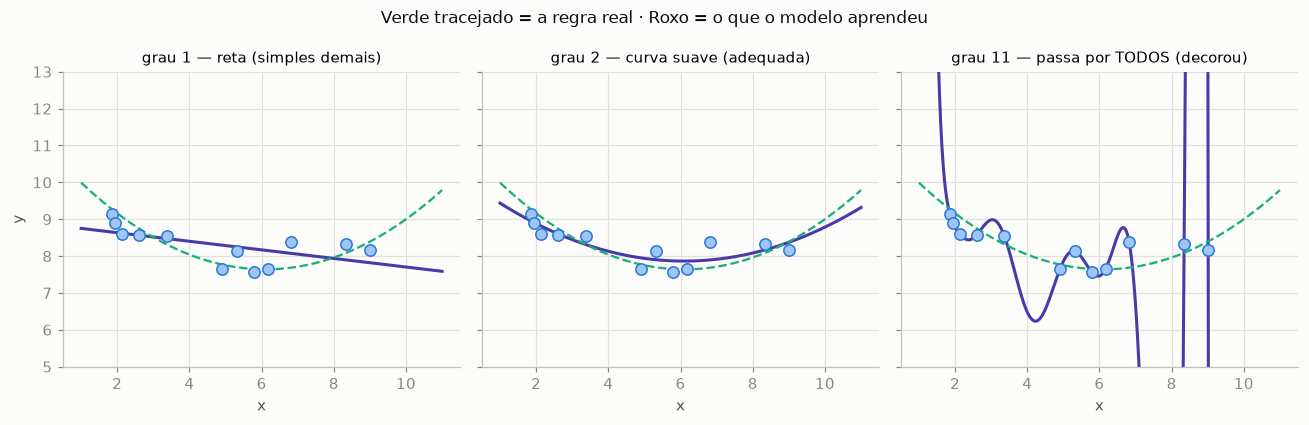

 grau |  erro no TREINO |  erro no TESTE | veredito
--------------------------------------------------------------
    1 |           0.387 |          0.722 | simples demais
    2 |           0.245 |          0.481 | bom
    3 |           0.236 |          0.527 | bom
    5 |           0.206 |          1.249 | DECOROU o ruído
    8 |           0.129 |         28.646 | DECOROU o ruído
   11 |           0.000 |       4659.194 | DECOROU o ruído

O erro no TREINO cai sempre — até virar zero no grau 11. Parece ótimo.
O erro no TESTE despenca, atinge o mínimo e depois EXPLODE. É o overfitting.

Se você avaliar o modelo nos dados em que ele treinou, o grau 11 parece perfeito.
Por isso a regra número 1 da avaliação: NUNCA avalie no conjunto de treino.


In [7]:
# --- Decorar não é aprender ---
rng2 = np.random.default_rng(3)

def verdade(x):
    return 11.0 - 1.10 * x + 0.09 * x ** 2          # a regra REAL, que ninguém conhece

x_treino = np.sort(rng2.uniform(1, 11, 12))          # 12 exemplos de treino
y_treino = verdade(x_treino) + rng2.normal(0, 0.45, 12)
x_teste = np.sort(rng2.uniform(1, 11, 40))           # casos NOVOS
y_teste = verdade(x_teste) + rng2.normal(0, 0.45, 40)

grade = np.linspace(1, 11, 300)
fig, eixos = plt.subplots(1, 3, figsize=(12, 3.9), sharey=True)

for eixo, grau, rotulo in zip(eixos, [1, 2, 11], ["reta (simples demais)",
                                                  "curva suave (adequada)",
                                                  "passa por TODOS (decorou)"]):
    coef = np.polyfit(x_treino, y_treino, grau)
    eixo.plot(grade, np.polyval(coef, grade), color=COR["treino"], linewidth=2)
    eixo.scatter(x_treino, y_treino, color=COR["dados"], edgecolor=COR["media"], s=55, zorder=3)
    eixo.plot(grade, verdade(grade), color=COR["verdade"], linestyle="--", linewidth=1.5)
    eixo.set_title(f"grau {grau} — {rotulo}", fontsize=9.5)
    eixo.set_ylim(5, 13); eixo.set_xlabel("x")

eixos[0].set_ylabel("y")
fig.suptitle("Verde tracejado = a regra real · Roxo = o que o modelo aprendeu",
             fontsize=11, color="#0b0b0b")
plt.tight_layout()
plt.show()

print(f"{'grau':>5} | {'erro no TREINO':>15} | {'erro no TESTE':>14} | veredito")
print("-" * 62)
for grau in [1, 2, 3, 5, 8, 11]:
    coef = np.polyfit(x_treino, y_treino, grau)
    e_tr = np.sqrt(np.mean((y_treino - np.polyval(coef, x_treino)) ** 2))
    e_te = np.sqrt(np.mean((y_teste - np.polyval(coef, x_teste)) ** 2))
    if grau == 1:
        v = "simples demais"
    elif e_te < 0.7:
        v = "bom"
    else:
        v = "DECOROU o ruído"
    print(f"{grau:>5} | {e_tr:>15.3f} | {e_te:>14.3f} | {v}")

print("\nO erro no TREINO cai sempre — até virar zero no grau 11. Parece ótimo.")
print("O erro no TESTE despenca, atinge o mínimo e depois EXPLODE. É o overfitting.")
print("\nSe você avaliar o modelo nos dados em que ele treinou, o grau 11 parece perfeito.")
print("Por isso a regra número 1 da avaliação: NUNCA avalie no conjunto de treino.")

> **A conexão com o Módulo 7:** o conjunto de treino é uma **amostra**. O modelo aprendeu o sinal
> **e** as peculiaridades daquela amostra específica. Quanto mais flexível o modelo, mais ele
> consegue absorver peculiaridades que não vão se repetir.
>
> É também um parente próximo da **extrapolação** do Módulo 5, §④: o grau 11 é confiável dentro
> da nuvem de pontos e delira fora dela.

**O que procurar num artigo:**

| Sinal de alerta | Por quê |
|---|---|
| não diz como separou treino e teste | pode estar reportando desempenho no treino |
| "ajustamos os parâmetros para maximizar o desempenho no teste" | o teste virou treino; precisa de um **terceiro** conjunto (validação) |
| conjunto de teste minúsculo | a estimativa balança demais (§④) |
| dados de teste **anteriores** aos de treino | vazamento: o modelo viu o futuro |

---
# ③ O desempenho médio esconde subgrupos

Aqui o curso fecha o círculo. No **primeiro módulo do primeiro dia**, você conheceu o tenente
Gilbert Daniels e os 4.063 pilotos: nenhum deles era "médio" nas 10 dimensões ao mesmo tempo, e
por isso a cabine projetada para o piloto médio não servia para **ninguém**.

Avaliar um modelo de IA por um número único é cometer exatamente o mesmo erro.

In [5]:
# --- Um modelo com ótimo desempenho geral e um buraco escondido ---
rng3 = np.random.default_rng(28)
NC = 4000

# 85% dos casos são de operação DIURNA; 15% são NOTURNA (sub-representada no treino)
noturno = rng3.random(NC) < 0.15

# o modelo funciona bem de dia e mal de noite (viu poucos exemplos noturnos)
acertou = np.where(noturno,
                   rng3.random(NC) < 0.61,      # 61% de acerto à noite
                   rng3.random(NC) < 0.95)      # 95% de acerto de dia

print(f"ACURÁCIA GERAL DO MODELO: {acertou.mean():.1%}   <- o número que vai no relatório\n")
print(f"{'condição':<22} | {'casos':>7} | {'% do total':>11} | {'acurácia':>9}")
print("-" * 58)
for rotulo, mask in [("operação diurna", ~noturno), ("operação NOTURNA", noturno)]:
    print(f"{rotulo:<22} | {mask.sum():>7} | {mask.mean():>10.1%} | {acertou[mask].mean():>8.1%}")

print(f"\nO número único ({acertou.mean():.1%}) é verdadeiro e é inútil para decidir.")
print("Ele é uma MÉDIA — e a média foi dominada pelo grupo maior, exatamente como no Módulo 1.")
print("\nSe a sua operação é noturna, esse modelo erra 2 em cada 5 casos.")
print("E o relatório nunca mentiu: ele só reportou o centro, e não a distribuição.")

ACURÁCIA GERAL DO MODELO: 89.5%   <- o número que vai no relatório

condição               |   casos |  % do total |  acurácia
----------------------------------------------------------
operação diurna        |    3380 |      84.5% |    94.5%
operação NOTURNA       |     620 |      15.5% |    61.9%

O número único (89.5%) é verdadeiro e é inútil para decidir.
Ele é uma MÉDIA — e a média foi dominada pelo grupo maior, exatamente como no Módulo 1.

Se a sua operação é noturna, esse modelo erra 2 em cada 5 casos.
E o relatório nunca mentiu: ele só reportou o centro, e não a distribuição.


> ### O piloto médio, de volta
>
> Daniels mostrou que **ninguém** é médio em todas as dimensões ao mesmo tempo. A versão em IA:
> **nenhuma condição real de operação é a "condição média"** para a qual o modelo foi avaliado.
>
> A solução da USAF não foi treinar pilotos diferentes — foi criar o **assento ajustável**. A
> solução em IA é a mesma em espírito: **avaliação desagregada**. Reporte o desempenho por
> subgrupo (por condição, por tipo de equipamento, por unidade, por faixa de horário), e não um
> número só.
>
> E note que este é também o **paradoxo de Simpson** do Módulo 6, §③, em roupa nova: o agregado
> pode ser excelente enquanto um subgrupo inteiro vai mal. **Sempre peça a quebra por subgrupo.**

---
# ④ "O modelo A tem 91,2% e o B tem 90,8%"

Frase típica de artigo, de *benchmark* e de apresentação comercial. E ela é uma **diferença entre
duas estimativas** — exatamente o objeto do Módulo 8.

**Antes de rodar:** se os dois modelos foram avaliados num conjunto de teste de 1.000 casos, essa
vantagem de 0,4 ponto significa alguma coisa?

In [6]:
# --- A vantagem de 0,4 ponto sobrevive ao acaso? ---
p_A, p_B = 0.912, 0.908

print(f"{'tamanho do teste':>18} | {'erro padrão':>12} | {'IC 95% da diferença':>26} | conclusão")
print("-" * 88)
for n in [200, 1_000, 10_000, 100_000]:
    ep_dif = np.sqrt(p_A * (1 - p_A) / n + p_B * (1 - p_B) / n)
    dif = p_A - p_B
    lo, hi = dif - 1.96 * ep_dif, dif + 1.96 * ep_dif
    veredito = "pode ser acaso" if lo <= 0 <= hi else "diferença real"
    print(f"{n:>18} | {ep_dif:>11.4f} | [{lo:>+7.4f} , {hi:>+7.4f}] | {veredito}")

print("\nCom 1.000 casos de teste, o intervalo vai de -2,1% a +2,9%: o zero está DENTRO.")
print("Ou seja: os dados são perfeitamente compatíveis com os dois modelos serem iguais —")
print("e até com o modelo B ser melhor.")
print("\nSó com dezenas de milhares de casos essa vantagem de 0,4 ponto vira detectável.")
print("\nE mesmo detectável, sobra a pergunta do Módulo 8, §④: 0,4 ponto MUDA alguma decisão?")

  tamanho do teste |  erro padrão |        IC 95% da diferença | conclusão
----------------------------------------------------------------------------------------
               200 |      0.0286 | [-0.0521 , +0.0601] | pode ser acaso
              1000 |      0.0128 | [-0.0211 , +0.0291] | pode ser acaso
             10000 |      0.0040 | [-0.0039 , +0.0119] | pode ser acaso
            100000 |      0.0013 | [+0.0015 , +0.0065] | diferença real

Com 1.000 casos de teste, o intervalo vai de -2,1% a +2,9%: o zero está DENTRO.
Ou seja: os dados são perfeitamente compatíveis com os dois modelos serem iguais —
e até com o modelo B ser melhor.

Só com dezenas de milhares de casos essa vantagem de 0,4 ponto vira detectável.

E mesmo detectável, sobra a pergunta do Módulo 8, §④: 0,4 ponto MUDA alguma decisão?


> **O que fazer com isso, na prática:**
>
> - **Peça o tamanho do conjunto de teste.** Sem ele, nenhuma comparação de acurácia é
>   interpretável.
> - **Desconfie de rankings decididos no terceiro decimal.** Boa parte das trocas de posição em
>   *leaderboards* está dentro do ruído amostral.
> - **Pergunte quantos modelos foram testados** antes de escolher o vencedor. Testar 50
>   configurações e reportar a melhor é o **p-hacking** do Módulo 8, §⑤, com outro nome — e a
>   vantagem da campeã costuma evaporar em dados novos.

---
# ⑤ O mundo mudou depois do treino

Um modelo aprende a distribuição dos dados com que foi treinado. Se a realidade da operação for
diferente daquela — porque mudou a estação, o terreno, o equipamento, o inimigo ou simplesmente o
tempo —, o desempenho cai **sem que nada no modelo tenha mudado**.

Isso se chama **deslocamento de distribuição**, e é a forma mais comum de um sistema que ia bem
"começar a falhar sozinho".

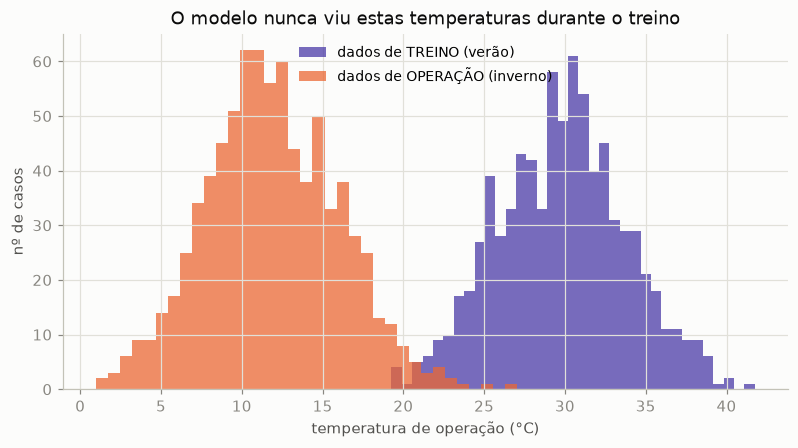

erro do modelo no verão   (onde treinou):   2.27
erro do modelo no inverno (na operação) :  18.42
o erro ficou 8x maior — sem NADA no modelo ter mudado.

E repare: a regra real do mundo NÃO mudou. Ela sempre foi curva.
O que mudou foi a FAIXA em que o modelo opera. Na faixa estreita do verão, uma reta
descrevia tudo muito bem; fora dela, a mesma reta é uma extrapolação (Módulo 5, §④).

Pior: o modelo continua respondendo com a mesma confiança de sempre. Ele não tem
como saber que saiu da faixa — quem tem que saber é você.


In [7]:
# --- Treinado no verão, operando no inverno ---
rng4 = np.random.default_rng(37)

# a regra REAL do fenômeno é curva (consumo cresce mais rápido em temperatura alta)
def regra_real(x):
    return 0.05 * x ** 2

# o modelo foi treinado no VERÃO e, naquela faixa estreita, uma reta descreve tudo muito bem
x_verao = rng4.normal(30, 4, 800)                       # temperatura de operação (°C)
y_verao = regra_real(x_verao) + rng4.normal(0, 2, 800)
coef = np.polyfit(x_verao, y_verao, 1)                  # o modelo: uma reta

# na operação real, o inverno chegou: a faixa de temperatura MUDOU
x_inverno = rng4.normal(12, 4, 800)
y_inverno = regra_real(x_inverno) + rng4.normal(0, 2, 800)

erro_verao = np.sqrt(np.mean((y_verao - np.polyval(coef, x_verao)) ** 2))
erro_inverno = np.sqrt(np.mean((y_inverno - np.polyval(coef, x_inverno)) ** 2))

plt.figure(figsize=(8.5, 4.2))
plt.hist(x_verao, bins=35, color=COR["treino"], alpha=0.75, label="dados de TREINO (verão)")
plt.hist(x_inverno, bins=35, color=COR["teste"], alpha=0.75, label="dados de OPERAÇÃO (inverno)")
plt.title("O modelo nunca viu estas temperaturas durante o treino", color="#0b0b0b")
plt.xlabel("temperatura de operação (°C)"); plt.ylabel("nº de casos")
plt.legend(frameon=False, fontsize=9)
plt.show()

print(f"erro do modelo no verão   (onde treinou): {erro_verao:>6.2f}")
print(f"erro do modelo no inverno (na operação) : {erro_inverno:>6.2f}")
print(f"o erro ficou {erro_inverno / erro_verao:.0f}x maior — sem NADA no modelo ter mudado.\n")
print("E repare: a regra real do mundo NÃO mudou. Ela sempre foi curva.")
print("O que mudou foi a FAIXA em que o modelo opera. Na faixa estreita do verão, uma reta")
print("descrevia tudo muito bem; fora dela, a mesma reta é uma extrapolação (Módulo 5, §④).")
print("\nPior: o modelo continua respondendo com a mesma confiança de sempre. Ele não tem")
print("como saber que saiu da faixa — quem tem que saber é você.")

---
# ⑥ Checklist: lendo um artigo ou proposta de IA

As perguntas abaixo cobrem a maior parte dos erros que você vai encontrar. Nenhuma delas exige
saber programar ou entender a arquitetura do modelo — **todas são estatística básica**.

**Sobre os dados** *(Dia 3, Módulo 7)*
1. De onde vieram os dados de treino? Quem foi **excluído** deles?
2. Qual a proporção de cada classe? O evento de interesse é raro?
3. A base foi coletada por **sorteio** ou por conveniência?

**Sobre a avaliação** *(este módulo, §① e §②)*
4. Treino e teste foram **separados**? Como?
5. Além da acurácia, quais são o **recall** e a **precisão**?
6. Qual erro é mais caro na minha operação — e o modelo foi ajustado pensando nisso?
7. Existe desempenho **por subgrupo**, ou só o número agregado?

**Sobre a comparação** *(Dia 3, Módulo 8)*
8. Qual o **tamanho** do conjunto de teste?
9. A diferença entre os modelos vem com **intervalo de confiança**?
10. Quantas configurações foram testadas antes de escolher a vencedora?

**Sobre a interpretação** *(Dia 2, Módulo 6)*
11. Alguém está lendo "variável importante" como **causa**?
12. A realidade de operação é a mesma dos dados de treino? *(§⑤)*

> Se as respostas 1, 4, 5 e 8 não estiverem no texto, **o resultado não é interpretável** — por
> melhor que seja o número apresentado.

---
# 🔻 Fechamento do Curso

Três dias, três perguntas. É este o resumo do que você leva:

> ### **O que esse número descreve? (Dia 1)**
> Média, mediana, dispersão e forma. Todo resumo tem perda, e você aprendeu a perguntar o que
> ficou de fora — porque a decisão costuma morar na **cauda**, não no centro.
>
> ### **O que ele relaciona? (Dia 2)**
> Correlação, regressão e causa. Relacionar é fácil; **interpretar** é difícil. Nenhum cálculo
> transforma observação em causa — só o desenho do estudo faz isso.
>
> ### **Quanto ele merece confiança? (Dia 3)**
> Origem dos dados, incerteza e evidência. O erro mais caro nunca é de conta: é de **coleta** —
> e nenhum intervalo de confiança avisa quando ele acontece.

**E a frase que fecha a disciplina:**

> Em inteligência artificial, o modelo é a parte **fácil** de julgar. A parte difícil sempre foi
> a estatística dos **dados** e da **avaliação** — e é exatamente essa parte que você acabou de
> aprender a ler.

Você não vai construir modelos com o que viu aqui. Vai fazer algo mais raro e mais necessário:
**vai saber que perguntas fazer** quando alguém trouxer um número — de um artigo, de uma empresa
ou de um sistema em operação — e disser que ele resolve o problema.

---
# ⑦ Exercícios

**Exercício 1 — Preveja antes de rodar.**

1. Na §①, se o corte for para −2,0 (alarme quase sempre), o que acontece com recall e precisão?
2. Na §②, o que aconteceria com o erro de teste do grau 11 se o treino tivesse 500 pontos em vez
   de 12?
3. Na §④, qual `n` de teste seria necessário para detectar uma diferença de **0,1** ponto?

**Exercício 2 — Mude um parâmetro.**

Na célula da §③, mude a proporção de operações noturnas de `0,15` para `0,45`, mantendo as
acurácias de 61% e 95%. Pergunta: a acurácia geral muda? O buraco no desempenho noturno mudou?
O que isso ensina sobre confiar no número agregado?

**Exercício 3 — Conserte o erro (conceitual, não de sintaxe).**

Uma proposta comercial afirma:

> "Nosso sistema de detecção de intrusão em perímetro atinge **97,3% de acurácia**, superando o
> concorrente (96,9%) em testes internos. O modelo identificou que o **horário** é a variável mais
> importante, o que prova que ataques são causados pelo período noturno. Recomendamos a compra."

Aponte **quatro** falhas. *(Dicas: §⓪, §④, e Módulo 6.)*

**Exercício 4 — Avalie a proposta (discussão em grupo).**

O comando recebe uma oferta de sistema de IA para triagem médica na guarnição: detecta uma
condição que ocorre em 2% dos militares, com **94% de acurácia**.

1. Que modelo trivial já atingiria 98%? O que isso diz sobre a oferta?
2. Que duas medidas você exige antes de qualquer decisão?
3. Nesse problema, qual erro é mais caro? Que corte você defenderia?
4. Que perguntas do checklist (§⑥) você faria por escrito ao fornecedor?
5. O sistema foi treinado com dados de um hospital civil de outra região. Que seção deste módulo
   se aplica?

---
## Resumo do módulo

| Medida / conceito | Responde | Cuidado |
|---|---|---|
| **Acurácia** | % de acertos | é uma **média**; inútil com classe rara |
| **Matriz de confusão** | abre os 4 casos | é dela que sai todo o resto |
| **Recall** | das ocorrências reais, quantas peguei | sobe às custas da precisão |
| **Precisão** | dos meus alarmes, quantos valiam | sobe às custas do recall |
| **Treino × teste** | o modelo generaliza? | avaliar no treino é enganar-se |
| **Overfitting** | decorou o ruído | erro de treino baixo **não** é boa notícia |
| **Avaliação por subgrupo** | para quem o modelo falha | o agregado esconde (Daniels) |
| **IC da diferença** | a vantagem é real? | sem `n` do teste, não dá para saber |

- **Acurácia é média** — e média esconde a cauda, como no Dia 1.
- **Os dois erros têm custos diferentes**, e quem conhece o custo é quem opera.
- **O conjunto de treino é uma amostra**: tudo do Módulo 7 se aplica a ele.

🏁 **Fim do curso.** Da média de um pelotão à avaliação de um modelo de IA, foi sempre a mesma
disciplina — e sempre as mesmas três perguntas.